# Практична робота №1
**Серяков Владислав, ФБ-61мп**

**Тема:** класифікація спаму за допомогою Scikit-learn.

Мета — підготувати дані, навчити п’ять класифікаторів, підібрати параметри та порівняти результати.

Обрав [Spambase (UCI)](https://archive.ics.uci.edu/dataset/94/spambase). У ньому 4601 лист і 57 числових ознак. Потрібно визначити, чи є лист спамом: `spam = 1` — спам, `spam = 0` — звичайний лист.

Автори даних: Hopkins, Reeber, Forman, Suermondt (1999). [DOI: 10.24432/C53G6X](https://doi.org/10.24432/C53G6X), ліцензія CC BY 4.0.

## 1. Завантаження та огляд даних

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 67
sns.set_theme(style="whitegrid")
df = pd.read_csv("spambase.csv")
print("Розмір:", df.shape)
print("Колонки:", df.columns.tolist())
display(df.head())
display(df.dtypes.rename("Тип даних").to_frame())
display(df.spam.value_counts().sort_index().rename("Кількість").to_frame())
print("Частки класів:")
print(df.spam.value_counts(normalize=True).sort_index().round(3))

Розмір: (4601, 58)
Колонки: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_fre

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


,Тип даних
word_freq_make,float64
word_freq_address,float64
word_freq_all,float64
word_freq_3d,float64
word_freq_our,float64
word_freq_over,float64
word_freq_remove,float64
word_freq_internet,float64
word_freq_order,float64
word_freq_mail,float64


,Кількість
spam,
0,2788
1,1813


Частки класів:
spam
0    0.606
1    0.394
Name: proportion, dtype: float64


Ознаки — частоти 48 слів, 6 символів і 3 характеристики послідовностей великих літер. Усі вони числові, тому категоріальне кодування не потрібне. Цільова змінна — `spam`.

## 2. Попередня обробка
Перевірю пропуски й дублікати. Повторні рядки видаляю, щоб однакові приклади не потрапили одночасно у train і test. Набори ознак із суперечливими мітками також вилучаю: за цими ознаками їх не можна однозначно розрізнити.

In [2]:
features = df.columns.drop("spam").tolist()
print("Пропуски:", df.isna().sum().sum())
print("Повні дублікати:", df.duplicated().sum())
assert df.notna().all().all(), "З’явилися пропуски — потрібно перевірити CSV"
assert set(df.spam.unique()) == {0, 1}
df = df.drop_duplicates().copy()
conflict = df.groupby(features)["spam"].transform("nunique") > 1
print("Рядки із суперечливими мітками після видалення повторів:", conflict.sum())
df = df.loc[~conflict].copy()
print("Розмір після очищення:", df.shape)
X = df[features]
y = df["spam"]

Пропуски: 0
Повні дублікати: 391
Рядки із суперечливими мітками після видалення повторів: 6
Розмір після очищення: (4204, 58)


## 3. Візуалізація та дослідження даних
Для графіків обрав частоти слів `free`, `money`, `remove`, символів `!`, `$` і кількість великих літер. Вони можуть відрізняти рекламні листи від звичайних. Для навчання залишаю всі 57 ознак.

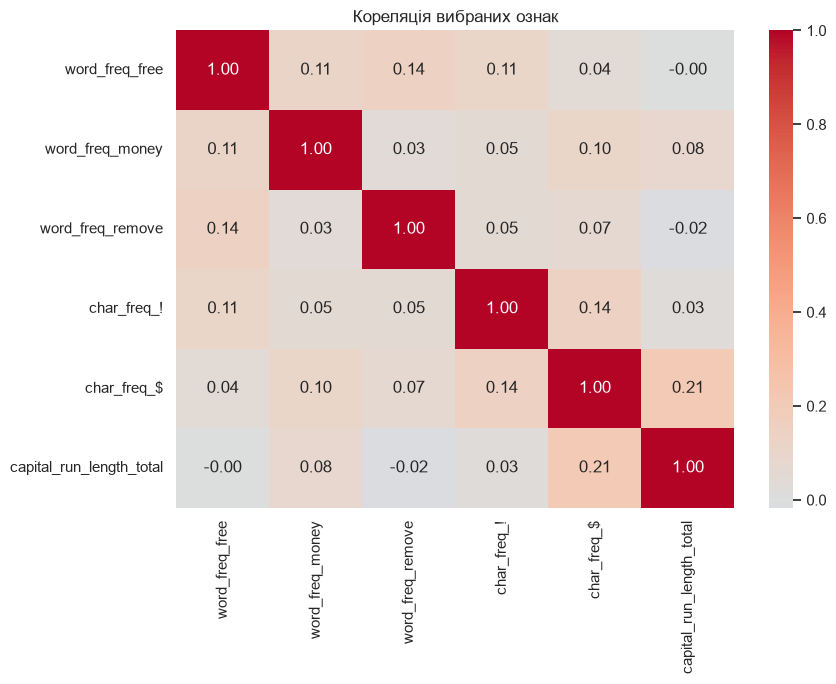

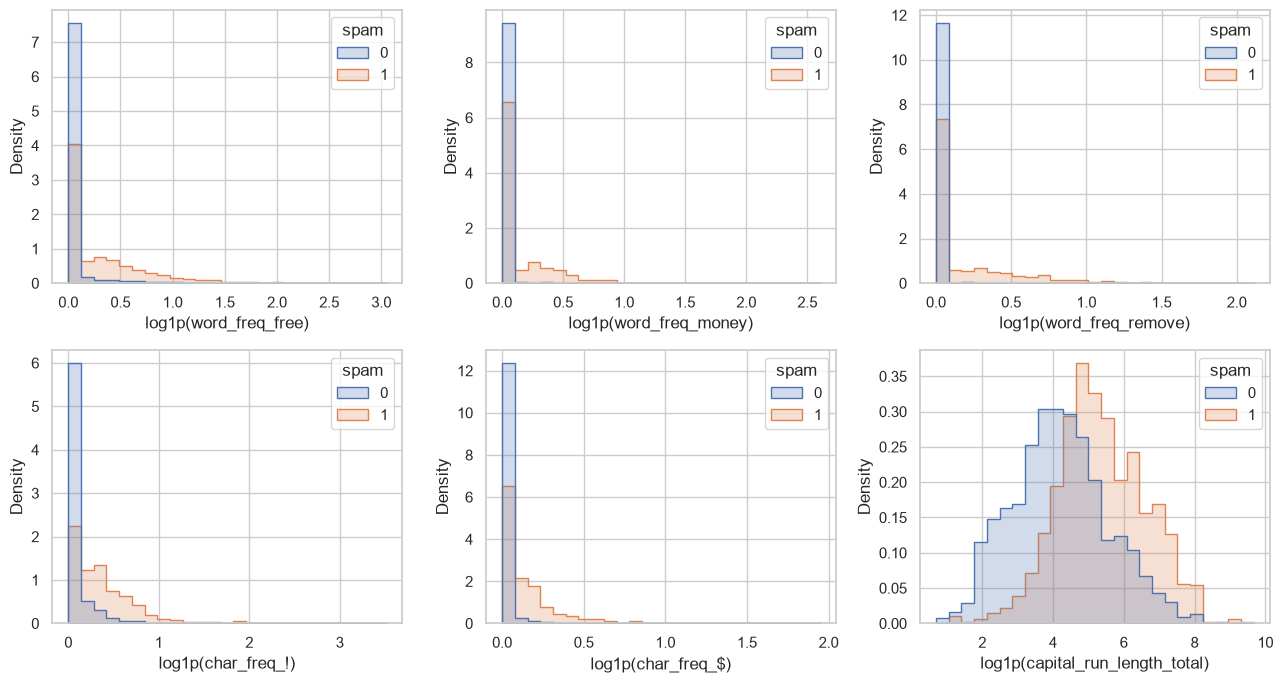

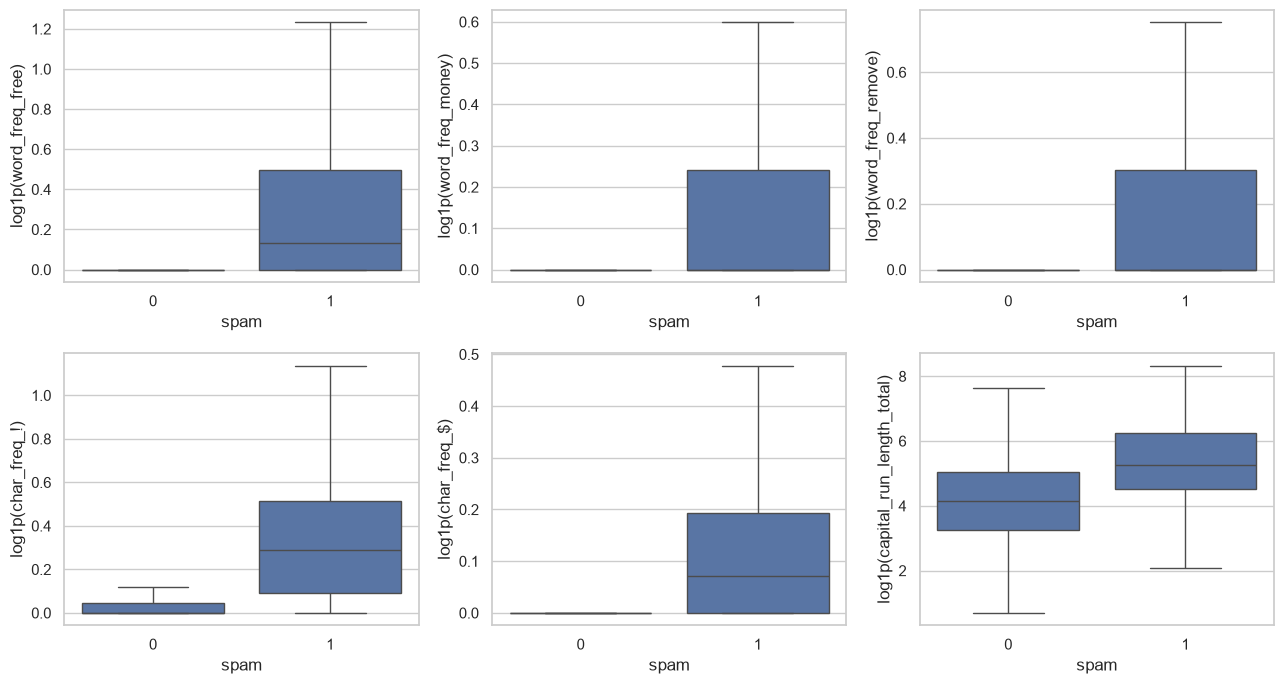

,word_freq_free,word_freq_money,word_freq_remove,char_freq_!,char_freq_$,capital_run_length_total
spam,,,,,,
0,0.072,0.019,0.009,0.121,0.012,174.222
1,0.528,0.200,0.281,0.524,0.172,467.295


In [3]:
selected = ["word_freq_free", "word_freq_money", "word_freq_remove",
            "char_freq_!", "char_freq_$", "capital_run_length_total"]
eda = df.copy()
plt.figure(figsize=(9, 7))
sns.heatmap(eda[selected].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Кореляція вибраних ознак")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, ax in zip(selected, axes.flat):
    # log1p дозволяє показати і нулі, і великі значення.
    sns.histplot(x=np.log1p(eda[col]), hue=eda.spam, bins=25,
                 stat="density", common_norm=False, element="step", ax=ax)
    ax.set_xlabel("log1p(" + col + ")")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, ax in zip(selected, axes.flat):
    sns.boxplot(x=eda.spam, y=np.log1p(eda[col]), showfliers=False, ax=ax)
    ax.set_ylabel("log1p(" + col + ")")
plt.tight_layout()
plt.show()
display(eda.groupby("spam")[selected].mean().round(3))

У більшості листів частоти вибраних слів і символів близькі до нуля. На графіках використав `log1p`, щоб великі значення не стискали решту розподілу. У самих даних значення не змінював. На boxplot приховав лише позначки викидів, а не видаляв рядки.

У спамі частіше зустрічаються слова `free`, `money` та символи `!`, `$`; великих літер зазвичай більше. Розподіли перекриваються, тому одного такого показника недостатньо. Heatmap показує слабкі лінійні зв’язки між вибраними ознаками.

## 4. Підготовка даних до навчання
Розділяю дані на 80% train і 20% test. `stratify=y` зберігає співвідношення класів, `random_state=67` дозволяє повторити розбиття.

Для kNN і SVM використовую StandardScaler, бо ці алгоритми залежать від відстаней між об’єктами. Масштабування виконується всередині Pipeline: під час CV scaler навчається тільки на відповідній навчальній частині. Деревам масштабування не потрібне. Test не використовую для вибору параметрів.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print("Train:", X_train.shape, "Test:", X_test.shape)
display(pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).sort_index())

Train: (3363, 57) Test: (841, 57)


,train,test
spam,,
0,2022,506
1,1341,335


## 5. Навчання моделей
Навчаю kNN, Decision Tree, SVM, Random Forest та AdaBoost на однаковій вибірці. Спочатку використовую стандартні параметри kNN і SVM, а в наступному розділі підберу їх через CV. Для дерева обмежую глибину до 10 і залишаю мінімум 2 об’єкти в листку, щоб зменшити перенавчання.

In [5]:
models = {
    "kNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=2, random_state=SEED),
    "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf"))]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=2),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=SEED)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "— навчено")

kNN — навчено
Decision Tree — навчено
SVM — навчено


Random Forest — навчено


AdaBoost — навчено


## 6. Підбір гіперпараметрів
Для kNN перевіряю `n_neighbors` від 3 до 21 за заданим списком. Для SVM перебираю `C` і `gamma` через GridSearchCV. `C` задає штраф за помилки, а `gamma` впливає на складність межі RBF-SVM.

Використовую 5-fold CV. Критерій — macro-F1, тобто середній F1 двох класів. Обрані параметри найкращі серед перевірених, а не серед усіх можливих.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
knn_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [3, 5, 7, 11, 15, 21]},
    cv=cv, scoring="f1_macro", n_jobs=2
)
svm_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf"))]),
    {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.001, 0.01, 0.1]},
    cv=cv, scoring="f1_macro", n_jobs=2
)
for name, grid in [("kNN", knn_grid), ("SVM", svm_grid)]:
    grid.fit(X_train, y_train)
    print(name, grid.best_params_, "CV macro-F1:", round(grid.best_score_, 4))
    display(pd.DataFrame(grid.cv_results_)[
        ["params", "mean_test_score", "std_test_score"]
    ].sort_values("mean_test_score", ascending=False))

kNN {'model__n_neighbors': 3} CV macro-F1: 0.908


,params,mean_test_score,std_test_score
0,{'model__n_neighbors': 3},0.908019,0.008716
1,{'model__n_neighbors': 5},0.900636,0.012063
2,{'model__n_neighbors': 7},0.893337,0.010640
3,{'model__n_neighbors': 11},0.886056,0.013870
4,{'model__n_neighbors': 15},0.885525,0.013526
5,{'model__n_neighbors': 21},0.879382,0.016021


SVM {'model__C': 10, 'model__gamma': 0.01} CV macro-F1: 0.9342


,params,mean_test_score,std_test_score
10,"{'model__C': 10, 'model__gamma': 0.01}",0.934173,0.005384
4,"{'model__C': 1, 'model__gamma': 'scale'}",0.928608,0.005143
6,"{'model__C': 1, 'model__gamma': 0.01}",0.927624,0.005700
9,"{'model__C': 10, 'model__gamma': 0.001}",0.925565,0.006257
8,"{'model__C': 10, 'model__gamma': 'scale'}",0.924087,0.002996
11,"{'model__C': 10, 'model__gamma': 0.1}",0.905102,0.008265
5,"{'model__C': 1, 'model__gamma': 0.001}",0.899351,0.013919
0,"{'model__C': 0.1, 'model__gamma': 'scale'}",0.898619,0.012656
2,"{'model__C': 0.1, 'model__gamma': 0.01}",0.898356,0.013330
7,"{'model__C': 1, 'model__gamma': 0.1}",0.896140,0.013195


In [7]:
models["kNN"] = knn_grid.best_estimator_
models["SVM"] = svm_grid.best_estimator_
cv_rows = []
for name, model in models.items():
    if name in ["kNN", "SVM"]:
        grid = knn_grid if name == "kNN" else svm_grid
        mean, std = grid.best_score_, grid.cv_results_["std_test_score"][grid.best_index_]
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=2)
        mean, std = scores.mean(), scores.std()
        model.fit(X_train, y_train)
    cv_rows.append({"model": name, "CV macro-F1": mean, "CV std": std})
cv_results = pd.DataFrame(cv_rows).set_index("model").sort_values("CV macro-F1", ascending=False)
best_model = cv_results.index[0]
display(cv_results.round(4))
print("Найкраща модель за CV:", best_model)

,CV macro-F1,CV std
model,,
Random Forest,0.9449,0.0090
SVM,0.9342,0.0054
AdaBoost,0.9300,0.0084
kNN,0.9080,0.0087
Decision Tree,0.9060,0.0109


Найкраща модель за CV: Random Forest


## 7. Оцінювання та порівняння
У classification_report: precision — точність передбачень класу, recall — частка знайдених об’єктів цього класу, F1 поєднує обидва показники. У confusion_matrix рядки — справжні класи, стовпці — прогноз; порядок `[0, 1]`. FP — звичайний лист, позначений як спам; FN — пропущений спам.


kNN
              precision    recall  f1-score   support

    not spam     0.8887    0.9308    0.9093       506
        spam     0.8875    0.8239    0.8545       335

    accuracy                         0.8882       841
   macro avg     0.8881    0.8774    0.8819       841
weighted avg     0.8882    0.8882    0.8874       841

Confusion matrix:
 [[471  35]
 [ 59 276]]

Decision Tree
              precision    recall  f1-score   support

    not spam     0.9032    0.9407    0.9216       506
        spam     0.9045    0.8478    0.8752       335

    accuracy                         0.9037       841
   macro avg     0.9038    0.8942    0.8984       841
weighted avg     0.9037    0.9037    0.9031       841

Confusion matrix:
 [[476  30]
 [ 51 284]]

SVM
              precision    recall  f1-score   support

    not spam     0.9184    0.9565    0.9371       506
        spam     0.9299    0.8716    0.8998       335

    accuracy                         0.9227       841
   macro avg     0.

              precision    recall  f1-score   support

    not spam     0.9390    0.9743    0.9564       506
        spam     0.9589    0.9045    0.9309       335

    accuracy                         0.9465       841
   macro avg     0.9490    0.9394    0.9436       841
weighted avg     0.9469    0.9465    0.9462       841

Confusion matrix:
 [[493  13]
 [ 32 303]]

AdaBoost
              precision    recall  f1-score   support

    not spam     0.9165    0.9545    0.9351       506
        spam     0.9268    0.8687    0.8968       335

    accuracy                         0.9203       841
   macro avg     0.9216    0.9116    0.9160       841
weighted avg     0.9206    0.9203    0.9199       841

Confusion matrix:
 [[483  23]
 [ 44 291]]


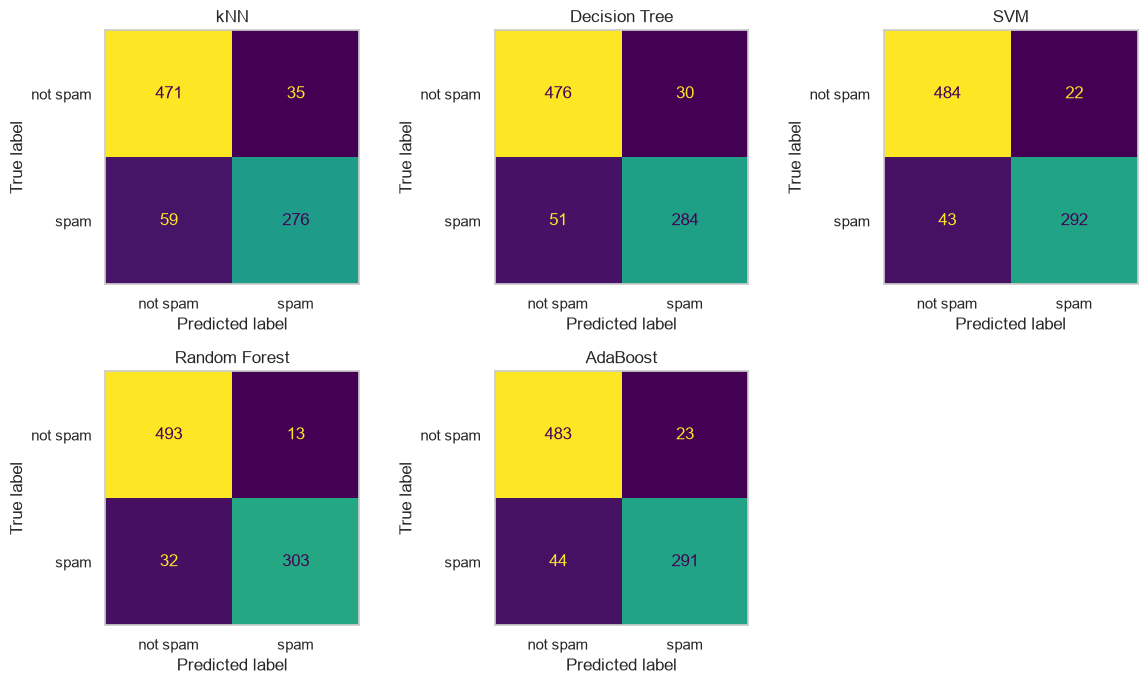

,accuracy,macro-F1,FP,FN
model,,,,
Random Forest,0.9465,0.9436,13,32
SVM,0.9227,0.9185,22,43
AdaBoost,0.9203,0.9160,23,44
Decision Tree,0.9037,0.8984,30,51
kNN,0.8882,0.8819,35,59


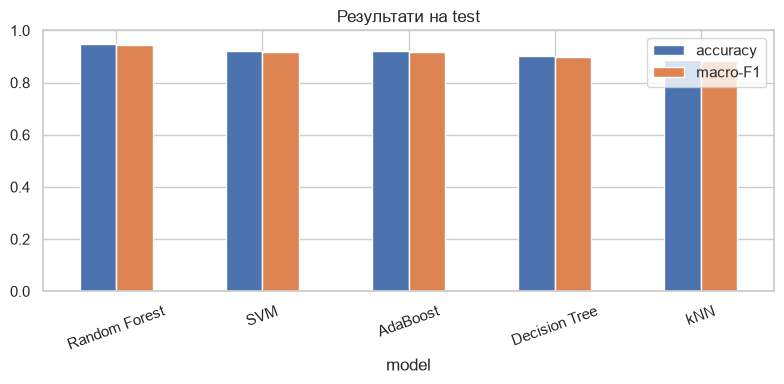

In [8]:
rows = []
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for (name, model), ax in zip(models.items(), axes.flat):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print("\n" + name)
    print(classification_report(y_test, pred, labels=[0, 1],
                                target_names=["not spam", "spam"], digits=4))
    print("Confusion matrix:\n", cm)
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                 "macro-F1": f1_score(y_test, pred, average="macro"),
                 "FP": fp, "FN": fn})
    ConfusionMatrixDisplay(cm, display_labels=["not spam", "spam"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(name)
    ax.grid(False)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()
results = pd.DataFrame(rows).set_index("model").sort_values("macro-F1", ascending=False)
display(results.round(4))
results[["accuracy", "macro-F1"]].plot.bar(figsize=(8, 4), rot=20, ylim=(0, 1))
plt.title("Результати на test")
plt.tight_layout()
plt.show()
results.to_csv("spambase_results.csv")

## Висновки

У роботі використав Spambase: 4601 лист, 57 числових ознак і цільову змінну `spam`. Спочатку було 2788 звичайних листів (60.6%) і 1813 спам-листів (39.4%). Пропусків і категоріальних ознак немає, тому заповнення та кодування не знадобилися. Видалив 391 повторний рядок і 6 рядків із суперечливими мітками. Залишилося 4204 приклади. Таке очищення трохи спрощує задачу: неоднозначні приклади не оцінюються.

На гістограмах видно багато нульових значень і довгі праві хвости. У спамі частоти `free`, `money`, `!`, `$` вищі; наприклад, середня частота `free` — 0.528% проти 0.072% у звичайних листах. Boxplot показує більшу кількість великих літер у спамі, але класи перекриваються. Лінійні кореляції між вибраними ознаками слабкі.

Дані розділив на 3363 навчальні та 841 тестовий приклад із `SEED = 67`. У test — 506 звичайних листів і 335 спам-листів. Для kNN і SVM застосував StandardScaler у Pipeline. За 5-fold CV найкращим для kNN виявилося `n_neighbors = 3` (macro-F1 = 0.9080), для SVM — `C = 10`, `gamma = 0.01` (macro-F1 = 0.9342).

Результати на test:

| Модель | Accuracy | Macro-F1 | Звичайні листи, помилково позначені як спам (FP) | Пропущений спам (FN) |
|---|---:|---:|---:|---:|
| kNN | 0.8882 | 0.8819 | 35 | 59 |
| Decision Tree | 0.9037 | 0.8984 | 30 | 51 |
| SVM | 0.9227 | 0.9185 | 22 | 43 |
| Random Forest | **0.9465** | **0.9436** | **13** | **32** |
| AdaBoost | 0.9203 | 0.9160 | 23 | 44 |

Найкращий результат показав **Random Forest**: він лідирує і за CV (macro-F1 = 0.9449), і на test. Правильно визначено 493 звичайні листи та 303 спам-листи. Для спаму precision = 0.9589, recall = 0.9045, F1 = 0.9309; для звичайних листів F1 = 0.9564. Отже, модель рідко блокує звичайну пошту, але частину спаму все ж пропускає.

SVM та AdaBoost дали близькі результати, а дерево і kNN пропустили більше спаму. У всіх моделей recall спаму нижчий, ніж recall звичайних листів. На мою думку, Random Forest краще підходить до цих даних, бо поєднує правила багатьох дерев і враховує комбінації ознак, які окреме дерево може не відтворити достатньо добре.

Ці результати стосуються обраного розбиття. Spambase зібрано 1999 року, тому якість на сучасній пошті потрібно перевіряти окремо. Після зміни seed або параметрів числові висновки потрібно оновити вручну.

Джерела: [Spambase](https://archive.ics.uci.edu/dataset/94/spambase), матеріали курсу [Pr_1](https://github.com/natsakh/IAD/tree/main/Pr_1) і [Pr_2](https://github.com/natsakh/IAD/tree/main/Pr_2).